In [ ]:
import pandas as pd
import seaborn as sns

# create a dataframe to store the titanic dataset
df=sns.load_dataset('titanic')

In [ ]:
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


# Section 1: Data Overview and Feature Identification

Understanding the structure of the data and dtypes

In [ ]:
# view first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# view the last 4 rows
df.tail(4)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
#identifying the general information about the dataset + check dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
# check dtypes of columns
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [ ]:
# identify numerical and categorical columns separately
num_col=df.select_dtypes(include=['int64','float64']).columns
num_col

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [ ]:
# compute the basic statistics
df.describe() # by default numeric

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# compute the statistics of categorical column
df.describe(include=['object','category'])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [ ]:
# statistics of all numeric + categorical
df.describe(include='all')
# those irrelevant to numeric is given NaN and vice versa

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Section 2: Handle missing value

In [ ]:
# check for missing values
df.isnull().sum() # simply will give true or false to make sense sums missing value per column

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
# analyze which strategy to apply
#-drop: the deck column(bcs more than 75% of data is missing in that column:688/891 are missing)
# - fill(stats/constant): age and embarked column

In [ ]:
# apply imputation separately for numerical and categorical columns

# Numeric col: fill using either mean or median--->age column(177 are missing)
# Categorical col: fill using mode value---> embarked(2 values are missing)

In [ ]:
# drop deck column---> df.drop(columns=['col1','col2','col3])
df=df.drop(columns=['deck'])
# if we re-run error because already dropped

In [ ]:
df.columns # lists out the column names

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [ ]:
# fill the age column with the column mean
# and age if i get a mean there is no meeaning so median is like the middle value considering even neighbours so thats better

# mean value of age column : df['age'].mean()
# median: df['age'].median()

# fill the MV of 'age' column with mean: df['column_name'].fillna(the calucated mean value)--->df['column name'].fillna(df['age'].mean())

df['age']=df['age'].fillna(df['age'].median())

In [ ]:
# fill the embarked column with column mode

# mode value of categorical col: df['cat_col_name'].mode()[0] (mode value is saved as a list,[0] means the first value)

# fill the MV of categorical column---> df['cat_col'].fillna(that categorical column mode value)--->df['cat_col'].fillna(df['cat_col'].mode()[0])
mode_value=df['embarked'].mode()[0]
df['embarked']=df['embarked'].fillna(mode_value)

In [ ]:
mode_value=df['embarked'].mode()
mode_value

,embarked
0,S


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


# Section3: Outlier detection and Handling

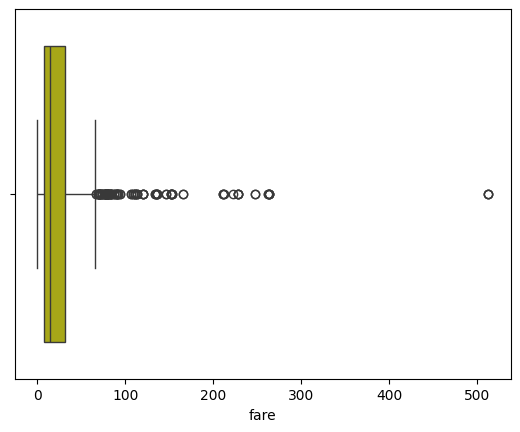

In [ ]:
# visulaization: boxplot

# libraries required are
# import seaborn as sns(already done) # has types of plot
import matplotlib.pyplot as plt # has requirements for plotting

# create the visual plot--->box
# boxplot for 'Fare' as money related value which can show variation based on other parameters
# but target here is survived which is already binary form and no meaning of outliers there
sns.boxplot(x=df['fare'],color='y') # in x axis
plt.show()

# min line # max line
# min=Q1-1.5*IQR
# the two ends of box Q1 and Q3  Q1=(N+1)/4
# the black line inside the box is the median
# outliers

In [ ]:
# IQR method
Q1=df['fare'].quantile(0.25)
Q3=df['fare'].quantile(0.75)
IQR=Q3-Q1
# can stretch upto this
lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)
# beyond this outlier
# df['fare']<lower_bound and df['fare']>upper_bound
outliers=df[(df['fare']<lower_bound)|(df['fare']>upper_bound)] #|and or join # df['condition'] will give the values satisfying it in the dataframe
outliers
# 116 outlier rows

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846,0,3,male,NaN,8,2,69.5500,S,Third,man,True,NaN,Southampton,no,False
849,1,1,female,NaN,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
856,1,1,female,45.0,1,1,164.8667,S,First,woman,False,NaN,Southampton,yes,False
863,0,3,female,NaN,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False


# Section4: Encoding Categorical data

In [ ]:
# nominal categories---> one hot encoding---> get_dummies
# ordinal(have order or rank)---> label---> sklearn.preprocessing LabelEncoder

# encode 'sex' ---> nominal category as only male or female no rank
df=pd.get_dummies(df,columns=['sex'],drop_first=True)
df.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_male
0,0,3,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,True
1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,False
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,False
3,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,False
4,0,3,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,True


In [ ]:
# ordinal categorical column ---> 'class'
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder() # copy of the class
df['class']=le.fit_transform(df['class'])
df.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_male
0,0,3,22.0,1,0,7.2500,S,2,man,True,Southampton,no,False,True
1,1,1,38.0,1,0,71.2833,C,0,woman,False,Cherbourg,yes,False,False
2,1,3,26.0,0,0,7.9250,S,2,woman,False,Southampton,yes,True,False
3,1,1,35.0,1,0,53.1000,S,0,woman,False,Southampton,yes,False,False
4,0,3,35.0,0,0,8.0500,S,2,man,True,Southampton,no,True,True


In [ ]:
# remove/drop the unnecessary columns
# columns=['who','adult_male','embark_town','alive','alone']
df=df.drop(columns=['who','adult_male','embark_town','alive','alone'])
df.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,sex_male
0,0,3,22.0,1,0,7.2500,S,2,True
1,1,1,38.0,1,0,71.2833,C,0,False
2,1,3,26.0,0,0,7.9250,S,2,False
3,1,1,35.0,1,0,53.1000,S,0,False
4,0,3,35.0,0,0,8.0500,S,2,True


In [ ]:
# embarked(nominal)--> here done using label as one step and here dosent make a difference later will scale as only 3 places either southampton or cherbroug getting down
# even though here it has assigned S as 2 its ok for upto 2 or 3 columns
# as otherwise again shd do scaling to avoid that.....not correct!!
df['embarked']=le.fit_transform(df['embarked'])
df.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,sex_male
0,0,3,22.0,1,0,7.2500,2,2,True
1,1,1,38.0,1,0,71.2833,0,0,False
2,1,3,26.0,0,0,7.9250,2,2,False
3,1,1,35.0,1,0,53.1000,2,0,False
4,0,3,35.0,0,0,8.0500,2,2,True


In [ ]:
# sex_male is numeric and not bool
df['sex_male']=df['sex_male'].astype(int) # instead of one hot encoder here since only 1 column we did using astype ie wherever its true there 1
df.head()
# now all data numeric

,survived,pclass,age,sibsp,parch,fare,embarked,class,sex_male
0,0,3,22.0,1,0,7.2500,2,2,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,2,2,0
3,1,1,35.0,1,0,53.1000,2,0,0
4,0,3,35.0,0,0,8.0500,2,2,1


# Section 5: Scaling and Normalization

In [ ]:
df.head()

,survived,pclass,age,sibsp,parch,fare,embarked,class,sex_male
0,0,3,22.0,1,0,7.2500,2,2,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,2,2,0
3,1,1,35.0,1,0,53.1000,2,0,0
4,0,3,35.0,0,0,8.0500,2,2,1


In [ ]:
# Scaling: 1.Standardization(Z score)  2.Min-max scaling

from sklearn.preprocessing import StandardScaler,MinMaxScaler

# standard scaler
ss=StandardScaler() # an instance
df_scaled=df.copy() # not changing to original directly as let it be there for safety
# instance name.fit_transform(label_encoder,le,if scaling ss)
df_scaled[['age','fare']]=ss.fit_transform(df_scaled[['age','fare']]) # to do both columns together
df_scaled

# Standardardization for bell curve-standard
# and for what columns what we can decide
# z-score formula based
# 0 for mean and 1 for std

,survived,pclass,age,sibsp,parch,fare,embarked,class,sex_male
0,0,3,-0.565736,1,0,-0.502445,2,2,1
1,1,1,0.663861,1,0,0.786845,0,0,0
2,1,3,-0.258337,0,0,-0.488854,2,2,0
3,1,1,0.433312,1,0,0.420730,2,0,0
4,0,3,0.433312,0,0,-0.486337,2,2,1
...,...,...,...,...,...,...,...,...,...
886,0,2,-0.181487,0,0,-0.386671,2,1,1
887,1,1,-0.796286,0,0,-0.044381,2,0,0
888,0,3,-0.104637,1,2,-0.176263,2,2,0
889,1,1,-0.258337,0,0,-0.044381,0,0,1


In [ ]:
# applying min max(normalization)- not always used
# used for known data range - between [0,1]- in algorithms (when we know the datarange and want it something b/w 0 and 1 for certain ML models)
mm=MinMaxScaler() # an instance
df_minmax=df.copy()
df_minmax[['age','fare']]=mm.fit_transform(df_minmax[['age','fare']])
df_minmax

,survived,pclass,age,sibsp,parch,fare,embarked,class,sex_male
0,0,3,0.271174,1,0,0.014151,2,2,1
1,1,1,0.472229,1,0,0.139136,0,0,0
2,1,3,0.321438,0,0,0.015469,2,2,0
3,1,1,0.434531,1,0,0.103644,2,0,0
4,0,3,0.434531,0,0,0.015713,2,2,1
...,...,...,...,...,...,...,...,...,...
886,0,2,0.334004,0,0,0.025374,2,1,1
887,1,1,0.233476,0,0,0.058556,2,0,0
888,0,3,0.346569,1,2,0.045771,2,2,0
889,1,1,0.321438,0,0,0.058556,0,0,1


# Section 6: Correlation analysis

<Axes: >

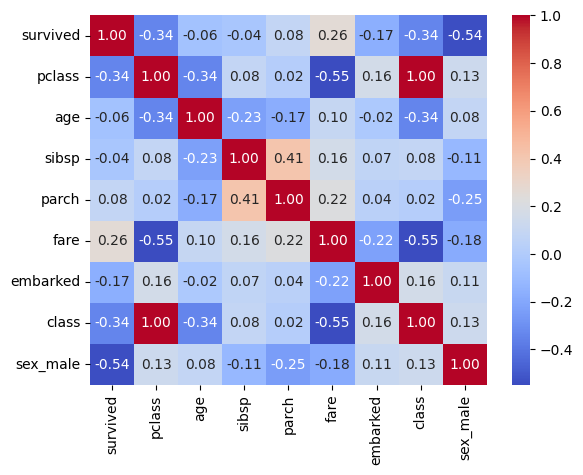

In [ ]:
# check on numerical columns

corr=df.corr() # to obtain the correlation matrix
#corr
# matrix # diagonal 1
# +ve and -ve correlation
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm') # rounding
# sibling spouses and parent children correlated
# sex_male vs survived - strong -ve correlation-females were evacuated
# fare vs passenger class
# cmap=Blues,Purples,BuPu,YlGn(yellow-Green),YlOrRd(yellow-orange-red),YlGnBu
# bwr,seismic,spectral,Set1,Set2,twilight,viridis,plasma,magma

# Section 7: Pre-processed Dataset

After cleaning+encoding+scaling,

1. which columns to be kept and useful to ML
2. which columns to be removed
3. which columns can lead to information leakage

## First Rule: what is the column that we are trying to predict

In [ ]:
df.head()

# Target column('survived'): the columns whose value we want to predict
# now i know how many survived now if we give new set of data it will predict
# rest of the columns:features

,survived,pclass,age,sibsp,parch,fare,embarked,class,sex_male
0,0,3,22.0,1,0,7.2500,2,2,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,2,2,0
3,1,1,35.0,1,0,53.1000,2,0,0
4,0,3,35.0,0,0,8.0500,2,2,1


## Second Rule: Identify those columns that must be dropped

- some columns are useful and some are not
- eg:name cannot tell whether a person are allowed to survived,Id no,ticket no,cabin no such columns if present can be removed
- here already we removed columns

In [ ]:
# to give to machine learning model

Check if multicolinearity and then remove those